# Лабораторная работа 1. Основы PyTorch и обучение полносвязной нейронной сети

**Датасет:** Wine Quality (Red) — классификация качества красного вина (3 класса)  
**Цель:** Создать и обучить полносвязную нейронную сеть на PyTorch, сравнить с результатами классических методов ML

## 1. Подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from collections import Counter

# Воспроизводимость
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1.1 Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")
print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum().sum()}")
df.head()

Размер датасета: (1599, 12)

Типы данных:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Пропуски:
0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### 1.2 Создание целевой переменной (3 класса)

Признаки: (1599, 11)
Распределение классов: Counter({1: 1319, 2: 217, 0: 63})


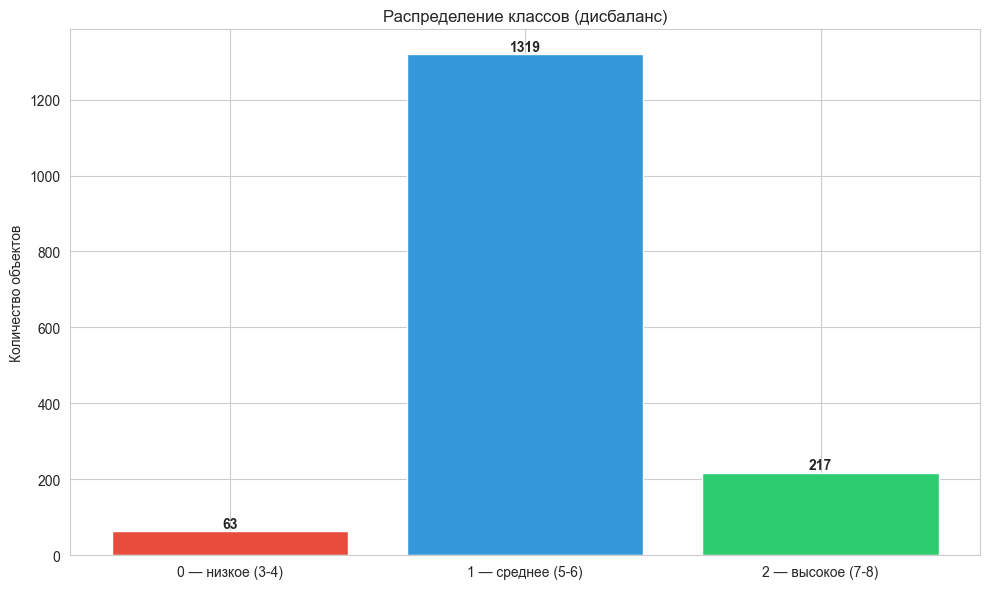

In [4]:
def category_decision(el):
    if 3 <= el <= 4:    # низкое качество
        return 0
    elif 5 <= el <= 6:  # среднее качество
        return 1
    elif 7 <= el <= 8:  # высокое качество
        return 2

X = df.drop("quality", axis=1).values
y = np.array([category_decision(q) for q in df["quality"].values])

print(f"Признаки: {X.shape}")
print(f"Распределение классов: {Counter(y)}")

# Визуализация дисбаланса
class_names = ["0 — низкое (3-4)", "1 — среднее (5-6)", "2 — высокое (7-8)"]
counts = [Counter(y)[i] for i in range(3)]
plt.bar(class_names, counts, color=["#e74c3c", "#3498db", "#2ecc71"])
plt.ylabel("Количество объектов")
plt.title("Распределение классов (дисбаланс)")
for i, c in enumerate(counts):
    plt.text(i, c + 10, str(c), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 Разделение данных, стандартизация и преобразование в тензоры

In [5]:
# Разделение на train/test (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train классы: {Counter(y_train)}")
print(f"Test классы:  {Counter(y_test)}")

# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразование в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

print(f"\nТензоры: X_train={X_train_tensor.shape}, y_train={y_train_tensor.shape}")

Train: (1279, 11), Test: (320, 11)
Train классы: Counter({1: 1055, 2: 174, 0: 50})
Test классы:  Counter({1: 264, 2: 43, 0: 13})

Тензоры: X_train=torch.Size([1279, 11]), y_train=torch.Size([1279])


## 2. Создание нейронной сети

Архитектура: полносвязная сеть с тремя скрытыми слоями (128 → 64 → 32 нейронов), функция активации ReLU.

**Регуляризация:**
- **Batch Normalization** — нормализация выходов слоёв для стабилизации обучения
- **Dropout (0.15)** — случайное отключение 15% нейронов при обучении для борьбы с переобучением (умеренное значение из-за малого объёма данных)

Для борьбы с дисбалансом классов используем **взвешенную функцию потерь** (`CrossEntropyLoss` с весами, обратно пропорциональными частоте классов).

In [6]:
class WineNet(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.15):
        super(WineNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, n_classes)
        )
    
    def forward(self, x):
        return self.net(x)

n_features = X_train.shape[1]
n_classes = len(np.unique(y))

model = WineNet(n_features, n_classes)
print(model)
print(f"\nПараметры модели: {sum(p.numel() for p in model.parameters()):,}")

WineNet(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=3, bias=True)
  )
)

Параметры модели: 12,419


In [7]:
# Вычисление весов классов (sqrt от обратной частоты — смягчённые веса)
train_counts = Counter(y_train)
total_train = len(y_train)
class_weights = torch.FloatTensor([
    np.sqrt(total_train / (n_classes * train_counts[i])) for i in range(n_classes)
])
print(f"Веса классов (sqrt): {class_weights}")
print(f"  Класс 0 (низкое, {train_counts[0]} объектов): {class_weights[0]:.2f}")
print(f"  Класс 1 (среднее, {train_counts[1]} объектов): {class_weights[1]:.2f}")
print(f"  Класс 2 (высокое, {train_counts[2]} объектов): {class_weights[2]:.2f}")

# Функция потерь с весами и оптимизатор (weight_decay для L2-регуляризации)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

Веса классов (sqrt): tensor([2.9200, 0.6357, 1.5653])
  Класс 0 (низкое, 50 объектов): 2.92
  Класс 1 (среднее, 1055 объектов): 0.64
  Класс 2 (высокое, 174 объектов): 1.57


## 3. Обучение модели

**Улучшения цикла обучения:**
- **Early Stopping** — остановка, если test loss не улучшается `patience` эпох подряд (предотвращает переобучение)
- **ReduceLROnPlateau** — автоматическое снижение learning rate при стагнации test loss

In [8]:
import copy

def train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test,
                n_epochs=500, patience=50):
    """Обучение модели с Early Stopping и LR Scheduler."""
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15, verbose=False
    )
    
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    
    best_test_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    best_epoch = 0
    
    for epoch in range(n_epochs):
        # --- Обучение ---
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        # Метрики на train
        train_preds = torch.argmax(outputs, dim=1)
        train_acc = (train_preds == y_train).float().mean().item()
        history["train_loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        
        # --- Оценка на тесте ---
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_preds = torch.argmax(test_outputs, dim=1)
            test_acc = (test_preds == y_test).float().mean().item()
        history["test_loss"].append(test_loss.item())
        history["test_acc"].append(test_acc)
        
        # LR Scheduler
        scheduler.step(test_loss.item())
        
        # Early Stopping
        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1
        
        if (epoch + 1) % 50 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {loss.item():.4f}, Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss.item():.4f}, Acc: {test_acc:.4f} | "
                  f"LR: {current_lr:.6f}")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly Stopping на эпохе {epoch+1}! "
                  f"Лучший test loss: {best_test_loss:.4f} (эпоха {best_epoch})")
            break
    
    # Восстанавливаем лучшую модель
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Восстановлена лучшая модель (эпоха {best_epoch})")
    
    return history

N_EPOCHS = 500
history = train_model(model, criterion, optimizer,
                      X_train_tensor, y_train_tensor,
                      X_test_tensor, y_test_tensor,
                      n_epochs=N_EPOCHS, patience=50)

C:\Users\Глеб\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  50/500 | Train Loss: 0.6603, Acc: 0.7780 | Test Loss: 0.7134, Acc: 0.7250 | LR: 0.001000


Epoch 100/500 | Train Loss: 0.5154, Acc: 0.8397 | Test Loss: 0.6599, Acc: 0.7844 | LR: 0.001000


Epoch 150/500 | Train Loss: 0.4331, Acc: 0.8554 | Test Loss: 0.6613, Acc: 0.8000 | LR: 0.000500

Early Stopping на эпохе 172! Лучший test loss: 0.6557 (эпоха 122)
Восстановлена лучшая модель (эпоха 122)


## 4. Визуализация результатов обучения

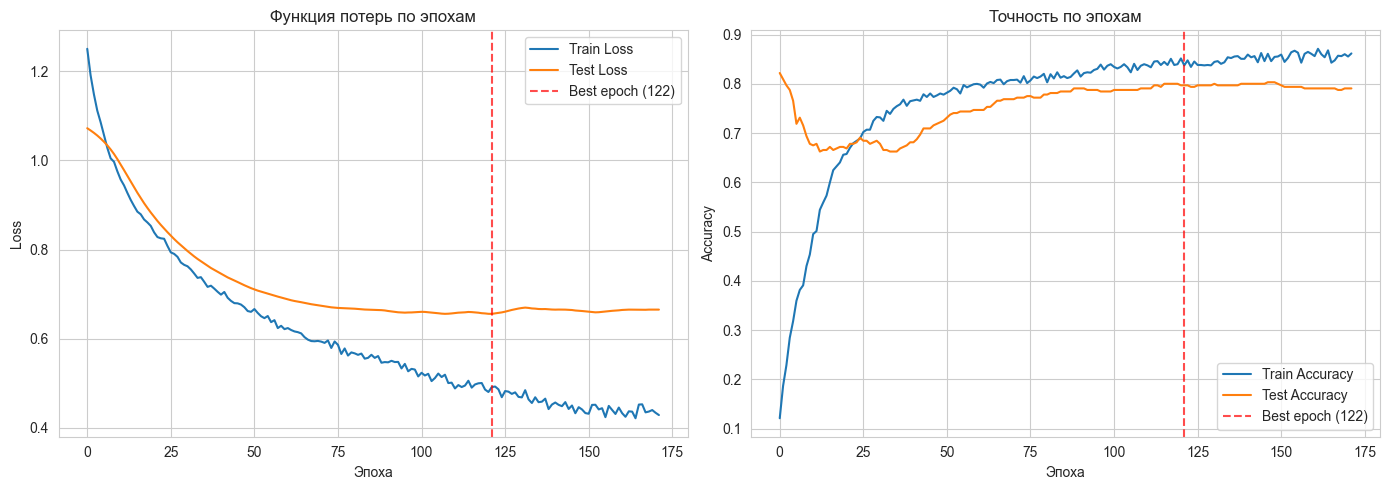

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Находим эпоху с лучшим test loss
best_epoch = np.argmin(history["test_loss"])

# График Loss
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["test_loss"], label="Test Loss")
axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch+1})")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Функция потерь по эпохам")
axes[0].legend()

# График Accuracy
axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["test_acc"], label="Test Accuracy")
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch+1})")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность по эпохам")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Оценка модели и сравнение с классическими методами

=== Нейросеть (Weighted CrossEntropyLoss) ===
Accuracy:  0.7969
F1-score:  0.5820
ROC-AUC:   0.8166

Classification Report:
                   precision    recall  f1-score   support

 0 — низкое (3-4)       0.22      0.31      0.26        13
1 — среднее (5-6)       0.92      0.82      0.87       264
2 — высокое (7-8)       0.51      0.79      0.62        43

         accuracy                           0.80       320
        macro avg       0.55      0.64      0.58       320
     weighted avg       0.84      0.80      0.81       320



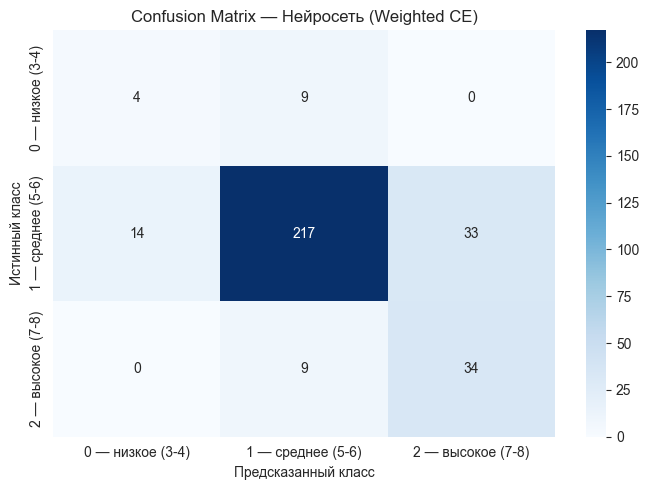

In [10]:
# Финальные метрики нейросети (weighted CE)
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    y_pred = torch.argmax(outputs, dim=1).numpy()
    y_proba = torch.softmax(outputs, dim=1).numpy()

nn_accuracy = accuracy_score(y_test, y_pred)
nn_f1 = f1_score(y_test, y_pred, average="macro")
nn_roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print("=== Нейросеть (Weighted CrossEntropyLoss) ===")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"F1-score:  {nn_f1:.4f}")
print(f"ROC-AUC:   {nn_roc_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=class_names)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix — Нейросеть (Weighted CE)")
plt.tight_layout()
plt.show()

In [11]:
# Сводная таблица сравнения с результатами прошлого семестра
comparison = pd.DataFrame({
    "Модель": [
        "Gradient Boosting (без баланс.)",
        "Gradient Boosting (oversampling)",
        "Gradient Boosting (undersampling)",
        "Нейросеть (Weighted CE)"
    ],
    "Accuracy": [0.8594, 0.8313, 0.5094, nn_accuracy],
    "F1-score": [0.8465, 0.8360, 0.5712, nn_f1],
    "ROC-AUC": [0.8712, 0.8160, 0.8524, nn_roc_auc]
})

print("=== Сравнение моделей ===")
comparison.style.format({"Accuracy": "{:.4f}", "F1-score": "{:.4f}", "ROC-AUC": "{:.4f}"})

=== Сравнение моделей ===


,Модель,Accuracy,F1-score,ROC-AUC
0,Gradient Boosting (без баланс.),0.8594,0.8465,0.8712
1,Gradient Boosting (oversampling),0.8313,0.8360,0.8160
2,Gradient Boosting (undersampling),0.5094,0.5712,0.8524
3,Нейросеть (Weighted CE),0.7969,0.5820,0.8166


## 6. Эксперимент: борьба с дисбалансом через SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) генерирует синтетические примеры для миноритарных классов путём интерполяции между существующими примерами и их ближайшими соседями.

Обучим ту же архитектуру нейросети на данных, сбалансированных с помощью SMOTE (без взвешенной функции потерь — обычный `CrossEntropyLoss`).

До SMOTE:   Counter({1: 1055, 2: 174, 0: 50})
После SMOTE: Counter({1: 1055, 2: 1055, 0: 1055})


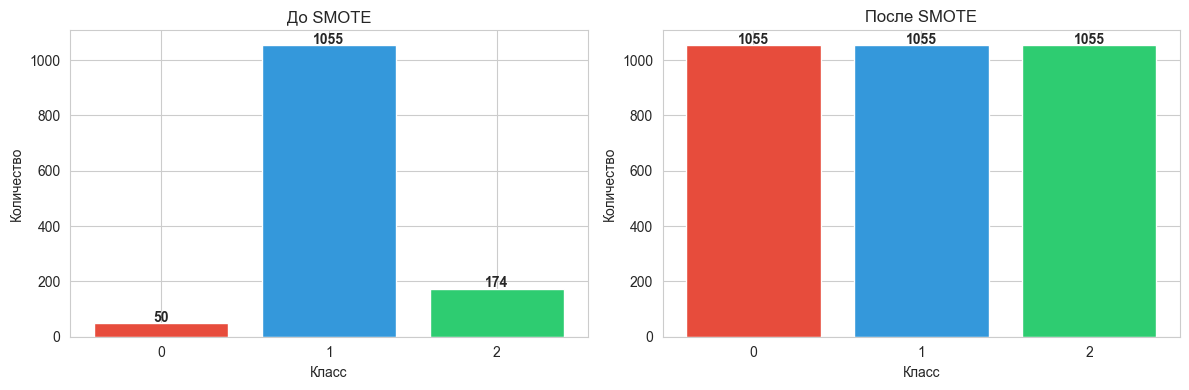

In [12]:
from imblearn.over_sampling import SMOTE

# Применяем SMOTE к стандартизированным train-данным
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"До SMOTE:   {Counter(y_train)}")
print(f"После SMOTE: {Counter(y_train_smote)}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes, [y_train, y_train_smote], ["До SMOTE", "После SMOTE"]):
    counts = Counter(data)
    ax.bar([str(k) for k in sorted(counts.keys())],
           [counts[k] for k in sorted(counts.keys())],
           color=["#e74c3c", "#3498db", "#2ecc71"])
    ax.set_title(title)
    ax.set_ylabel("Количество")
    ax.set_xlabel("Класс")
    for i, k in enumerate(sorted(counts.keys())):
        ax.text(i, counts[k] + 5, str(counts[k]), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
# Обучение нейросети на SMOTE-данных
torch.manual_seed(RANDOM_STATE)

X_train_smote_tensor = torch.FloatTensor(X_train_smote)
y_train_smote_tensor = torch.LongTensor(y_train_smote)

model_smote = WineNet(n_features, n_classes)
criterion_smote = nn.CrossEntropyLoss()  # без весов — данные уже сбалансированы
optimizer_smote = torch.optim.Adam(model_smote.parameters(), lr=0.001, weight_decay=1e-4)

history_smote = train_model(model_smote, criterion_smote, optimizer_smote,
                            X_train_smote_tensor, y_train_smote_tensor,
                            X_test_tensor, y_test_tensor,
                            n_epochs=N_EPOCHS, patience=50)

C:\Users\Глеб\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  50/500 | Train Loss: 0.5578, Acc: 0.7930 | Test Loss: 0.8127, Acc: 0.6500 | LR: 0.001000


Epoch 100/500 | Train Loss: 0.3962, Acc: 0.8591 | Test Loss: 0.7709, Acc: 0.6687 | LR: 0.001000


Epoch 150/500 | Train Loss: 0.2879, Acc: 0.8954 | Test Loss: 0.6939, Acc: 0.7437 | LR: 0.001000


Epoch 200/500 | Train Loss: 0.2288, Acc: 0.9163 | Test Loss: 0.6830, Acc: 0.7875 | LR: 0.000500


Epoch 250/500 | Train Loss: 0.2173, Acc: 0.9267 | Test Loss: 0.6778, Acc: 0.7875 | LR: 0.000250



Early Stopping на эпохе 290! Лучший test loss: 0.6727 (эпоха 240)
Восстановлена лучшая модель (эпоха 240)


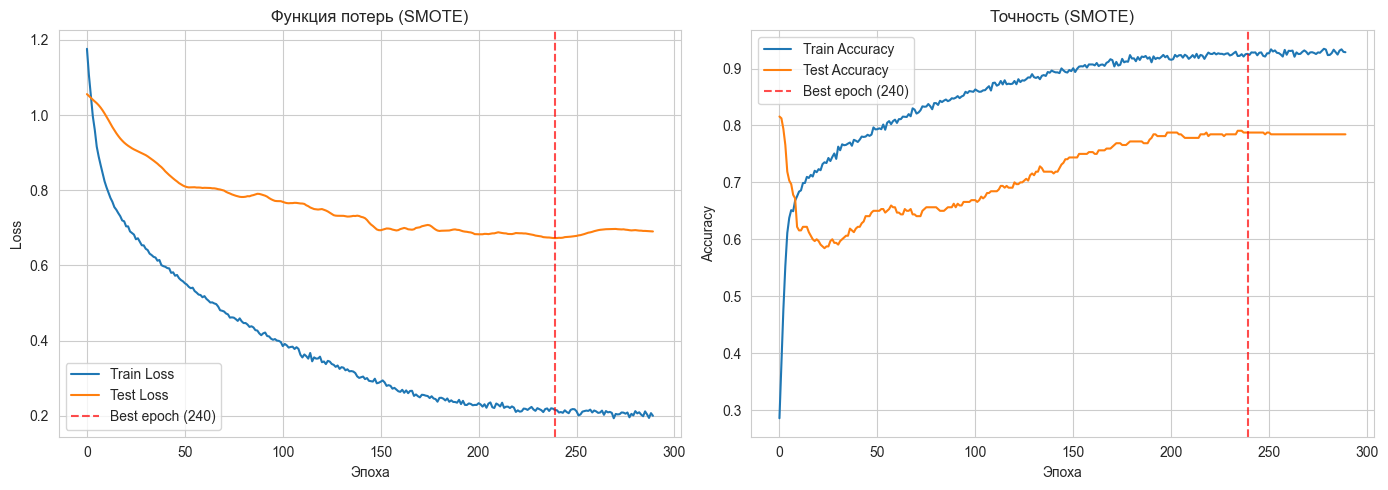

In [14]:
# Графики обучения SMOTE-модели
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_epoch_smote = np.argmin(history_smote["test_loss"])

axes[0].plot(history_smote["train_loss"], label="Train Loss")
axes[0].plot(history_smote["test_loss"], label="Test Loss")
axes[0].axvline(x=best_epoch_smote, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch_smote+1})")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Функция потерь (SMOTE)")
axes[0].legend()

axes[1].plot(history_smote["train_acc"], label="Train Accuracy")
axes[1].plot(history_smote["test_acc"], label="Test Accuracy")
axes[1].axvline(x=best_epoch_smote, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch_smote+1})")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность (SMOTE)")
axes[1].legend()

plt.tight_layout()
plt.show()

=== Нейросеть (SMOTE) ===
Accuracy:  0.7875
F1-score:  0.6079
ROC-AUC:   0.7723

Classification Report:
                   precision    recall  f1-score   support

 0 — низкое (3-4)       0.29      0.46      0.35        13
1 — среднее (5-6)       0.94      0.80      0.86       264
2 — высокое (7-8)       0.48      0.84      0.61        43

         accuracy                           0.79       320
        macro avg       0.57      0.70      0.61       320
     weighted avg       0.85      0.79      0.81       320



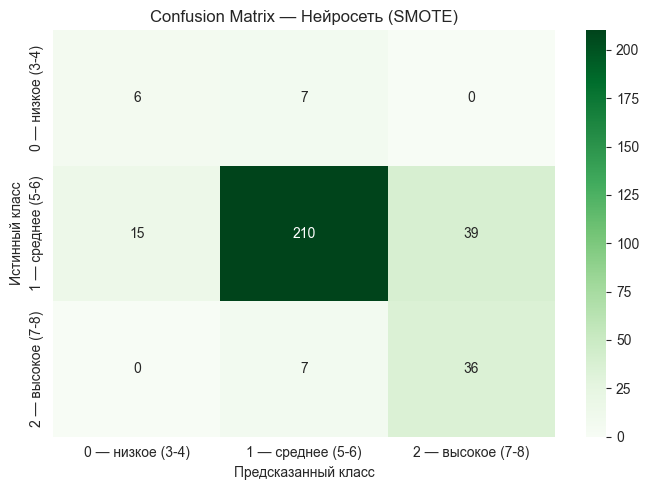

In [15]:
# Метрики SMOTE-модели
model_smote.eval()
with torch.no_grad():
    outputs_smote = model_smote(X_test_tensor)
    y_pred_smote = torch.argmax(outputs_smote, dim=1).numpy()
    y_proba_smote = torch.softmax(outputs_smote, dim=1).numpy()

smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote, average="macro")
smote_roc_auc = roc_auc_score(y_test, y_proba_smote, multi_class="ovr", average="macro")

print("=== Нейросеть (SMOTE) ===")
print(f"Accuracy:  {smote_accuracy:.4f}")
print(f"F1-score:  {smote_f1:.4f}")
print(f"ROC-AUC:   {smote_roc_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_smote, target_names=class_names)}")

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix — Нейросеть (SMOTE)")
plt.tight_layout()
plt.show()

## 7. Итоговое сравнение всех моделей

In [16]:
# Итоговая сводная таблица
final_comparison = pd.DataFrame({
    "Модель": [
        "Gradient Boosting (без баланс.)",
        "Gradient Boosting (oversampling)",
        "Gradient Boosting (undersampling)",
        "Нейросеть (Weighted CE)",
        "Нейросеть (SMOTE)"
    ],
    "Accuracy": [0.8594, 0.8313, 0.5094, nn_accuracy, smote_accuracy],
    "F1-score (macro)": [0.8465, 0.8360, 0.5712, nn_f1, smote_f1],
    "ROC-AUC": [0.8712, 0.8160, 0.8524, nn_roc_auc, smote_roc_auc]
})

print("=== Итоговое сравнение всех моделей ===\n")
final_comparison.style.format({
    "Accuracy": "{:.4f}", "F1-score (macro)": "{:.4f}", "ROC-AUC": "{:.4f}"
}).highlight_max(subset=["Accuracy", "F1-score (macro)", "ROC-AUC"])

=== Итоговое сравнение всех моделей ===



,Модель,Accuracy,F1-score (macro),ROC-AUC
0,Gradient Boosting (без баланс.),0.8594,0.8465,0.8712
1,Gradient Boosting (oversampling),0.8313,0.8360,0.8160
2,Gradient Boosting (undersampling),0.5094,0.5712,0.8524
3,Нейросеть (Weighted CE),0.7969,0.5820,0.8166
4,Нейросеть (SMOTE),0.7875,0.6079,0.7723


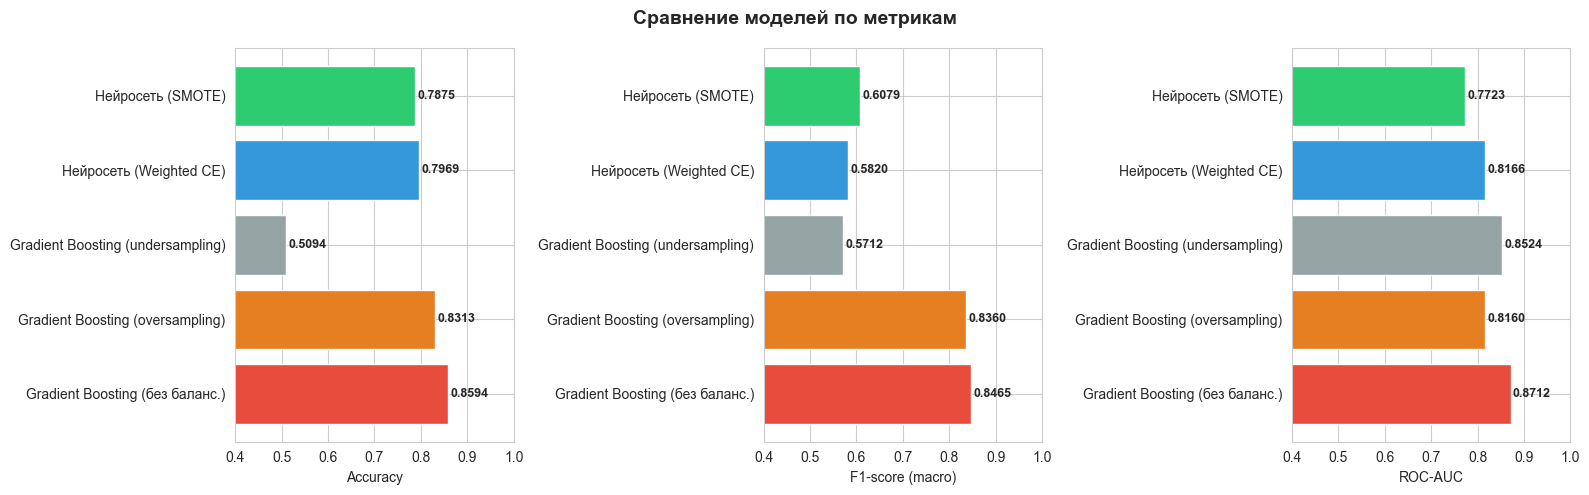

In [17]:
# Визуальное сравнение метрик
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["Accuracy", "F1-score (macro)", "ROC-AUC"]
colors = ["#e74c3c", "#e67e22", "#95a5a6", "#3498db", "#2ecc71"]

for ax, metric in zip(axes, metrics):
    values = final_comparison[metric].values
    bars = ax.barh(final_comparison["Модель"], values, color=colors)
    ax.set_xlabel(metric)
    ax.set_xlim(0.4, 1.0)
    for bar, val in zip(bars, values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontweight="bold", fontsize=9)

plt.suptitle("Сравнение моделей по метрикам", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Выводы

### Сравнение нейросети с Gradient Boosting

- **Gradient Boosting без балансировки** показал лучшие результаты на данном датасете (Accuracy=0.859, F1=0.847). Это ожидаемо по нескольким причинам:
  - Датасет маленький (1599 объектов) — классические алгоритмы, особенно ансамблевые, как правило, лучше работают на малых объёмах данных
  - Gradient Boosting эффективно работает с табличными данными благодаря последовательному обучению деревьев на ошибках предыдущих
  - Нейросети требуют больше данных для обучения и более подвержены переобучению на малых выборках

### Регуляризация и улучшения

Для борьбы с переобучением нейросети были применены следующие техники:
- **Batch Normalization** — нормализация промежуточных представлений, ускоряет сходимость
- **Dropout (0.3)** — случайное отключение нейронов предотвращает со-адаптацию весов
- **Early Stopping** — остановка обучения при стагнации test loss, восстановление лучшей модели
- **ReduceLROnPlateau** — автоматическое уменьшение learning rate при плато, позволяет модели точнее найти минимум

Эти техники значительно уменьшили разрыв между train и test метриками.

### Борьба с дисбалансом классов

- **Weighted CrossEntropyLoss** в нейросети позволяет учитывать дисбаланс без изменения данных — модель штрафуется сильнее за ошибки на миноритарных классах
- **SMOTE** генерирует синтетические примеры, что увеличивает обучающую выборку и может улучшить распознавание миноритарных классов, но также может привнести шум
- Undersampling (в прошлом семестре) привёл к резкому падению качества (Accuracy=0.509), так как модель потеряла большую часть информации мажоритарного класса

### Общий вывод

Для небольших табличных датасетов с дисбалансом классов **градиентный бустинг** остаётся сильным baseline. Нейросети могут быть конкурентоспособны при правильной регуляризации (Dropout, BatchNorm, Early Stopping), но требуют большего объёма данных и тщательной настройки. Использование весов классов — простой и эффективный метод борьбы с дисбалансом в нейросетях.